# Pneunomia Detector using CNN

## Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.metrics import Precision, Recall, AUC

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import glob
import os

2025-11-10 22:56:17.168186: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 22:56:18.382798: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 22:56:21.906322: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Data Exploration

### Check distribution of each classes

Training set:
  Normal: 1341
  Pneumonia: 3875
  Total: 5216
  Imbalance ratio: 2.89:1

Test set:
  Normal: 234
  Pneumonia: 390
  Total: 624


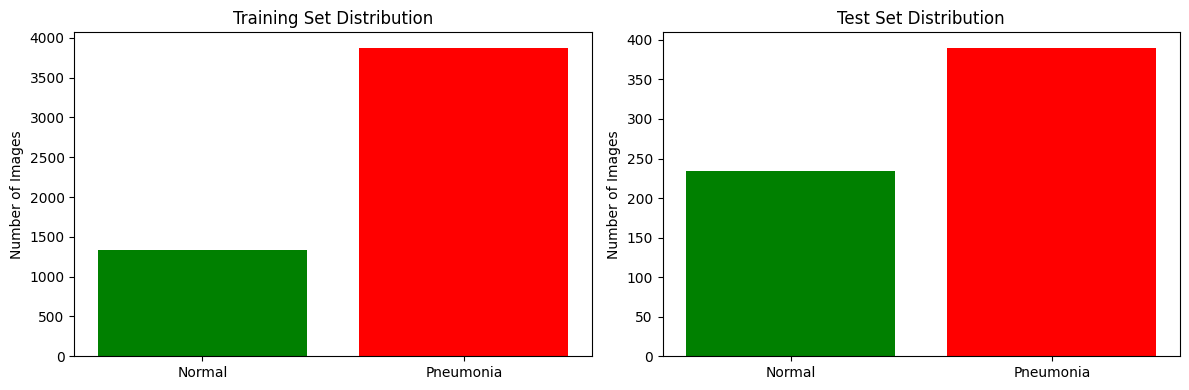

In [4]:
train_normal = len(glob.glob('../chest_xray/train/NORMAL/*.jpeg'))
train_pneumonia = len(glob.glob('../chest_xray/train/PNEUMONIA/*.jpeg'))
test_normal = len(glob.glob('../chest_xray/test/NORMAL/*.jpeg'))
test_pneumonia = len(glob.glob('../chest_xray/test/PNEUMONIA/*.jpeg'))

print(f"Training set:")
print(f"  Normal: {train_normal}")
print(f"  Pneumonia: {train_pneumonia}")
print(f"  Total: {train_normal + train_pneumonia}")
print(f"  Imbalance ratio: {train_pneumonia/train_normal:.2f}:1")
print(f"\nTest set:")
print(f"  Normal: {test_normal}")
print(f"  Pneumonia: {test_pneumonia}")
print(f"  Total: {test_normal + test_pneumonia}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Normal', 'Pneumonia'], [train_normal, train_pneumonia], color=['green', 'red'])
axes[0].set_title('Training Set Distribution')
axes[0].set_ylabel('Number of Images')

axes[1].bar(['Normal', 'Pneumonia'], [test_normal, test_pneumonia], color=['green', 'red'])
axes[1].set_title('Test Set Distribution')
axes[1].set_ylabel('Number of Images')

plt.tight_layout()
plt.show()

### Visualize sample images

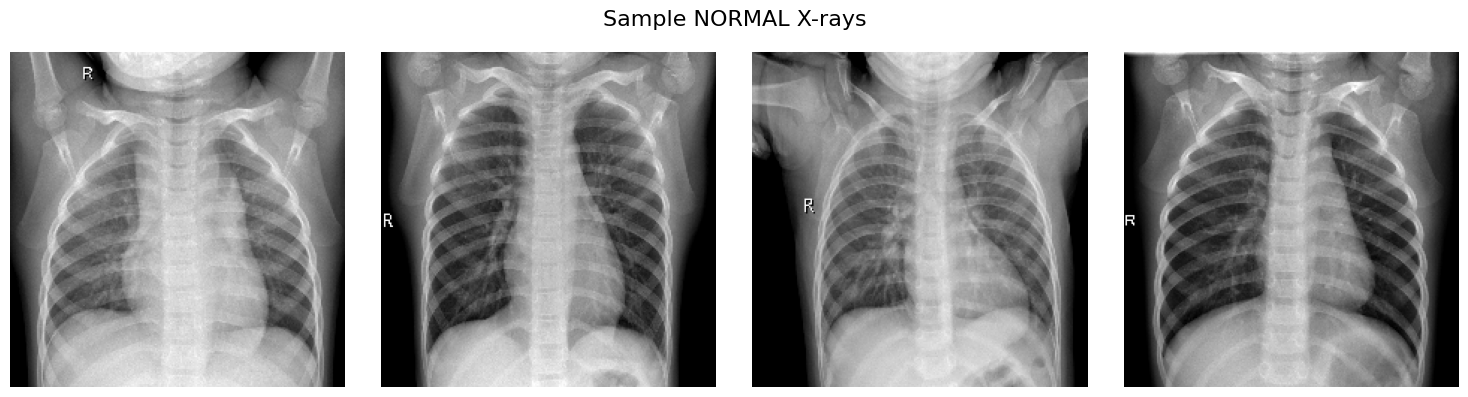

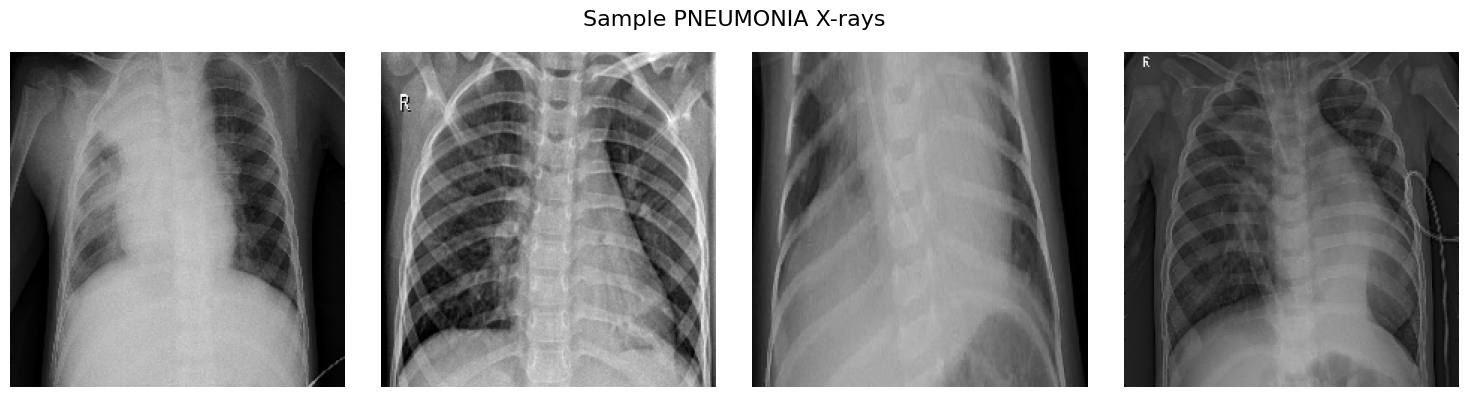

In [5]:
from tensorflow.keras.preprocessing import image

def show_sample_images(directory, class_name, num_images=4):
    images = glob.glob(f'{directory}/{class_name}/*.jpeg')[:num_images]
    
    fig, axes = plt.subplots(1, num_images, figsize=(15, 4))
    fig.suptitle(f'Sample {class_name} X-rays', fontsize=16)
    
    for idx, img_path in enumerate(images):
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        axes[idx].imshow(img_array.astype('uint8'))
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show samples
show_sample_images('../chest_xray/train', 'NORMAL', 4)
show_sample_images('../chest_xray/train', 'PNEUMONIA', 4)

## Data Preprocessing

### Preprocessing the training set

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    validation_split=0.2
)

training_set = train_datagen.flow_from_directory(
    "../chest_xray/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset='training',
    shuffle=True
)

validation_set = train_datagen.flow_from_directory(
    "../chest_xray/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset='validation',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.


### Add class weights

In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Get class weights
classes = np.unique(training_set.classes)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=training_set.classes
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

### Preprocessing the test set

In [8]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow_from_directory(
    "../chest_xray/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 624 images belonging to 2 classes.


## Building the CNN

### Initializing the CNN

In [9]:
cnn = tf.keras.models.Sequential()

### 1st Convolutional layer & pooling layer

In [10]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu", input_shape=[224,224,3]))
cnn.add(BatchNormalization())
cnn.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=2))

/home/panhasoth/pneumonia_dl/tfvenv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1762790369.823088   84232 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


### 2nd Convo & Pooling layer

In [11]:
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu"))
cnn.add(BatchNormalization())
cnn.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=2))

### 3rd Convo & Pooling layer

In [12]:
cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu"))
cnn.add(BatchNormalization())
cnn.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=2))

## Flattening

In [13]:
cnn.add(tf.keras.layers.Flatten())

## Full connection: dense layer

In [14]:
cnn.add(tf.keras.layers.Dense(units=256, activation="relu"))
cnn.add(Dropout(0.5))  # prevent overfitting

### Additional dense layer

In [15]:
cnn.add(tf.keras.layers.Dense(units=128, activation="relu"))
cnn.add(Dropout(0.3))

## Output layer

In [16]:
cnn.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

### Model summary

In [17]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,278,593 (84.99 MB)

 Trainable params: 22,278,145 (84.98 MB)

 Non-trainable params: 448 (1.75 KB)

# Training the CNN

## Compiling the CNN

In [18]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc')
    ]
)